In [1]:
import pandas as pd
import numpy as np

#%pip install matplotlib
#%pip install yfinance
%pip install --upgrade yfinance
%pip install hmmlearn
%pip install --upgrade matplolib
from scipy import stats

import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

%matplotlib inline


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement matplolib (from versions: none)
ERROR: No matching distribution found for matplolib

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
df_cesi = pd.read_csv('data/processed/cesi_limpo.csv', index_col =0, parse_dates = True)

In [3]:
#teste
dados_spy = yf.download("SPY", start="2004-01-01")

[*********************100%***********************]  1 of 1 completed


In [4]:
print(dados_spy.head())

Price           Close       High        Low       Open    Volume
Ticker            SPY        SPY        SPY        SPY       SPY
Date                                                            
2004-01-02  73.644180  74.279785  73.313136  73.981842  38072300
2004-01-05  74.445282  74.498245  73.882502  73.948715  27959800
2004-01-06  74.518120  74.637296  74.153969  74.259906  20472800
2004-01-07  74.769730  74.855799  74.081156  74.412201  30170400
2004-01-08  75.067650  75.087517  74.663775  74.981580  36438400


In [5]:
dados_spy


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2004-01-02,73.644180,74.279785,73.313136,73.981842,38072300
2004-01-05,74.445282,74.498245,73.882502,73.948715,27959800
2004-01-06,74.518120,74.637296,74.153969,74.259906,20472800
2004-01-07,74.769730,74.855799,74.081156,74.412201,30170400
2004-01-08,75.067650,75.087517,74.663775,74.981580,36438400
...,...,...,...,...,...
2026-08-10,773.030029,775.049988,771.619995,772.599976,39249500
2026-08-11,770.559998,774.609985,769.200012,774.530029,36740600


In [6]:
dados_spy.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5690 entries, 2004-01-02 to 2026-08-14
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   5690 non-null   float64
 1   (High, SPY)    5690 non-null   float64
 2   (Low, SPY)     5690 non-null   float64
 3   (Open, SPY)    5690 non-null   float64
 4   (Volume, SPY)  5690 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 266.7 KB


In [7]:
preco_spy = dados_spy['Close']

retornos_spy = np.log(preco_spy/preco_spy.shift(1))

retornos_spy.head()

Ticker,SPY
Date,
2004-01-02,NaN
2004-01-05,0.010819
2004-01-06,0.000978
2004-01-07,0.003371
2004-01-08,0.003977


In [8]:
df_modelo = pd.concat([retornos_spy, df_cesi['cesi_global']], axis=1).dropna()
df_modelo.columns = ['Retorno_SPY', 'CESI_Global']

df_modelo.head()

,Retorno_SPY,CESI_Global
Date,,
2004-01-05,0.010819,40.5
2004-01-06,0.000978,38.5
2004-01-07,0.003371,38.1
2004-01-08,0.003977,35.1
2004-01-09,-0.008770,32.2


In [9]:
dados_modelo = pd.concat([retornos_spy, df_cesi], axis=1).dropna()

print(dados_modelo.head())

                 SPY  cesi_global  cesi_g10  cesi_united_states  \
Date                                                              
2004-01-05  0.010819         40.5      55.5                71.6   
2004-01-06  0.000978         38.5      52.7                65.0   
2004-01-07  0.003371         38.1      50.7                62.3   
2004-01-08  0.003977         35.1      50.1                61.4   
2004-01-09 -0.008770         32.2      45.0                47.7   

            cesi_eurozone  cesi_asia_pacific  cesi_latin_america  \
Date                                                               
2004-01-05           53.6               36.3               -36.1   
2004-01-06           54.7               34.8               -35.1   
2004-01-07           52.1               37.7               -34.0   
2004-01-08           51.7               36.9               -39.9   
2004-01-09           52.6               36.3               -35.8   

            cesi_emerging_markets  cesi_bric  
Date  

In [10]:
df_feat = dados_modelo.copy()


df_feat = df_feat.rename(columns={'SPY': 'retorno'})

window = 14 

In [11]:
if isinstance(preco_spy, pd.DataFrame):
    preco_spy_serie = preco_spy.iloc[:, 0] 
else:
    preco_spy_serie = preco_spy

horizonte = 10
retorno_futuro = np.log(preco_spy_serie.shift(-horizonte) / preco_spy_serie)

limiar_tendencia = retorno_futuro.std() * 0.5  

def rotular(r):
    if r > limiar_tendencia:
        return 'Alta'
    elif r < -limiar_tendencia:
        return 'Baixa'
    else:
        return 'Lateral'

df_feat['label'] = retorno_futuro.reindex(df_feat.index).apply(
    lambda r: rotular(r) if pd.notna(r) else np.nan
)

In [12]:
from scipy.stats import linregress

df_feat['volatilidade'] = df_feat['retorno'].rolling(window).std()

df_feat['retorno_acumulado'] = df_feat['retorno'].rolling(window).sum()


def trend_r2(serie_precos):
    if serie_precos.isna().any():
        return np.nan
    x = np.arange(len(serie_precos))
    slope, _, r_value, _, _ = linregress(x, serie_precos.values)
    return (r_value ** 2) * np.sign(slope)

preco_spy_serie_feat = preco_spy_serie.reindex(df_feat.index)

window_longo = window * 3  

df_feat['trend_r2'] = preco_spy_serie_feat.rolling(window).apply(trend_r2, raw=False)
df_feat['trend_r2_longo'] = preco_spy_serie_feat.rolling(window_longo).apply(trend_r2, raw=False)

def autocorr_lag1(serie):
    if serie.isna().any() or serie.std() == 0:
        return np.nan
    return serie.autocorr(lag=1)


In [13]:
df_feat['autocorr'] = df_feat['retorno'].rolling(window).apply(autocorr_lag1, raw=False)

df_feat = df_feat.dropna()
df_feat[['retorno', 'volatilidade', 'retorno_acumulado', 'autocorr']].describe()

,retorno,volatilidade,retorno_acumulado,autocorr
count,5628.000000,5628.000000,5628.000000,5628.000000
mean,0.000404,0.009621,0.005679,-0.101589
std,0.011797,0.007009,0.038481,0.240323
min,-0.115887,0.001546,-0.315347,-0.803437
25%,-0.003944,0.005577,-0.010432,-0.267419
50%,0.000729,0.007789,0.011039,-0.102175
75%,0.005763,0.011308,0.026489,0.066078
max,0.135577,0.068276,0.212221,0.728202


In [14]:
features_stage1 = ['volatilidade', 'trend_r2', 'trend_r2_longo', 'autocorr']
X1 = df_feat[features_stage1].values

scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

modelo_stage1 = GaussianHMM(n_components=3, covariance_type='full', n_iter=1000, random_state=42)
modelo_stage1.fit(X1_scaled)

df_feat['estado_stage1'] = modelo_stage1.predict(X1_scaled)

resumo_stage1 = df_feat.groupby('estado_stage1')[features_stage1].mean()
print(resumo_stage1)

resumo_stage1['trend_medio'] = resumo_stage1[['trend_r2', 'trend_r2_longo']].mean(axis=1)

estado_alta = resumo_stage1['trend_medio'].idxmax()
estado_baixa = resumo_stage1['trend_medio'].idxmin()
estado_lateral = [e for e in resumo_stage1.index if e not in (estado_alta, estado_baixa)][0]

nomes_estado = {estado_alta: 'Alta', estado_baixa: 'Baixa', estado_lateral: 'Lateral'}

df_feat['regime_principal'] = df_feat['estado_stage1'].map(nomes_estado)
df_feat['regime_principal'].value_counts()


               volatilidade  trend_r2  trend_r2_longo  autocorr
estado_stage1                                                  
0                  0.018159 -0.103477       -0.311424 -0.122716
1                  0.008309  0.154298        0.180228 -0.071499
2                  0.005488  0.429422        0.787219 -0.126372


regime_principal
Lateral    2456
Alta       1883
Baixa      1289
Name: count, dtype: int64

In [15]:
n_estados = modelo_stage1.n_components

transmat = pd.DataFrame(
    modelo_stage1.transmat_,
    index=[f'De_{nomes_estado[i]}' for i in range(n_estados)],
    columns=[f'Para_{nomes_estado[i]}' for i in range(n_estados)]
)
print(transmat)


for i in range(n_estados):
    prob_permanecer = modelo_stage1.transmat_[i, i]
    duracao_esperada = 1 / (1 - prob_permanecer)
    print(f"Estado {nomes_estado[i]}: prob. de permanecer = {prob_permanecer:.3f} | duracao media esperada = {duracao_esperada:.1f} dias")


              Para_Baixa  Para_Lateral     Para_Alta
De_Baixa    9.684554e-01      0.031545  1.642558e-75
De_Lateral  1.673170e-02      0.959520  2.374839e-02
De_Alta     8.574921e-45      0.031445  9.685554e-01
Estado Baixa: prob. de permanecer = 0.968 | duracao media esperada = 31.7 dias
Estado Lateral: prob. de permanecer = 0.960 | duracao media esperada = 24.7 dias
Estado Alta: prob. de permanecer = 0.969 | duracao media esperada = 31.8 dias


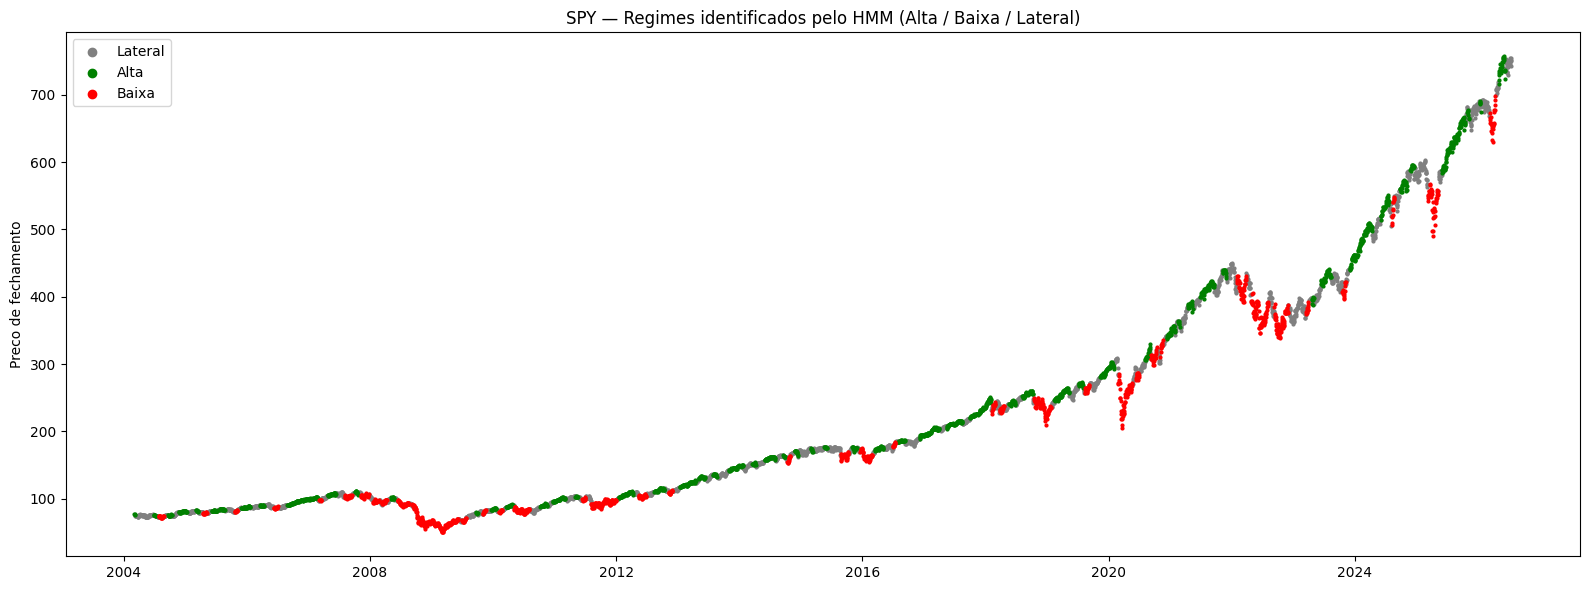

In [16]:
fig, ax = plt.subplots(figsize=(16, 6))

cores = {'Lateral': 'gray', 'Alta': 'green', 'Baixa': 'red'}

preco_plot = preco_spy_serie.reindex(df_feat.index)

for regime, cor in cores.items():
    mask = df_feat['regime_principal'] == regime
    ax.scatter(df_feat.index[mask], preco_plot[mask], c=cor, s=4, label=regime)

ax.set_title('SPY — Regimes identificados pelo HMM (Alta / Baixa / Lateral)')
ax.set_ylabel('Preco de fechamento')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()


In [17]:
resumo_stage1

,volatilidade,trend_r2,trend_r2_longo,autocorr,trend_medio
estado_stage1,,,,,
0,0.018159,-0.103477,-0.311424,-0.122716,-0.207451
1,0.008309,0.154298,0.180228,-0.071499,0.167263
2,0.005488,0.429422,0.787219,-0.126372,0.608320


In [18]:
df_feat['regime_principal'].value_counts()

regime_principal
Lateral    2456
Alta       1883
Baixa      1289
Name: count, dtype: int64